# **Prequisites**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Importings**

## Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer, LabelEncoder

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,5)

## Dataset

In [3]:
base_dir = '/content/drive/My Drive/power_transformer_fault_diagnosis/datasets/'
df = pd.read_csv(base_dir + 'Kaggle Transformer Dataset.csv')
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0


# **Peseudo-Labeling using Duval Triangle**

In [4]:
def duval_triangle(ch4_relative, c2h4_relative, c2h2_relative):
  
  if ch4_relative >= 98: status = 'PD'
  elif ch4_relative < 98 and c2h4_relative < 20 and c2h2_relative < 4: status = 'T1'
  elif 50 > c2h4_relative >= 20 and c2h2_relative < 4: status = 'T2'
  elif c2h4_relative >= 50 and c2h2_relative < 15: status = 'T3'
  elif c2h4_relative < 50 and 13 > c2h2_relative >= 4: status = 'DT'
  elif 40 <= c2h4_relative < 50 and 29 > c2h2_relative >= 13: status = 'DT'
  elif 50 <= c2h4_relative and 29 > c2h2_relative >= 15: status = 'DT'
  elif 23 < c2h4_relative and c2h2_relative >= 13: status = 'D1'
  elif 23 <= c2h4_relative and c2h2_relative >= 29: status = 'D2'
  elif 23 <= c2h4_relative < 40 and 29 > c2h2_relative >= 13: status = 'D2'
  else: status = 'other'

  return status

In [5]:
duval_state = []

for index, row in df.iterrows():

  ch4_relative = row['Methane']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
  c2h4_relative = row['Ethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
  c2h2_relative = row['Acethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100

  duval_state.append(duval_triangle(ch4_relative, c2h4_relative, c2h2_relative))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in double_scalars
  """
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in double_scalars
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in double_scalars
  import sys


In [6]:
df['duval_state'] = duval_state
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation,duval_state
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0,T3
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0,PD
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0,other
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0,PD
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0,T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0,T3
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0,T3
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5,PD
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0,PD


In [7]:
df['duval_state'].value_counts()

PD       166
T3       153
other     63
T2        58
T1        16
D1         8
DT         6
Name: duval_state, dtype: int64

In [8]:
labelencoder= LabelEncoder()
df['duval_state_encoded'] = labelencoder.fit_transform(df['duval_state'])

In [9]:
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation,duval_state,duval_state_encoded
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0,T3,5
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0,PD,2
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0,other,6
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0,PD,2
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0,T1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0,T3,5
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0,T3,5
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5,PD,2
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0,PD,2


# **Data Preprocessing and Preparation**

## Train/Test Split

In [10]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=25)

## Target / Feature Declaration

In [11]:
x_train = df_train.iloc[:, :14]
y_train = df_train.iloc[:, [14,15]]
z_train = df_train.iloc[:, -1]

x_test = df_test.iloc[:, :14]
y_test = df_test.iloc[:, [14,15]]
z_test = df_test.iloc[:, -1]

In [12]:
x_train

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3
336,7,492,9748,1,54,221,0,0,0,1.0,0.46,47,66,3
290,22,1220,49900,3,30,813,5,291,0,0.0,1.00,32,57,27
363,5,15700,60200,10,507,5330,19,14,0,0.0,19.70,40,55,17
97,0,944,58700,6,266,3530,8,11,0,153.0,0.35,40,56,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,4,9600,55200,7,785,2690,0,0,0,0.0,1.00,33,57,14
317,8,5570,22800,2,323,989,0,0,0,0.0,1.00,32,38,24
143,4,279,20000,8,285,4230,0,4,0,2.0,0.22,44,55,3
318,8,8470,44500,3,318,569,12,0,0,0.0,1.00,32,51,18


In [13]:
y_train

,Health index,Life expectation
4,85.2,6.0
336,13.4,51.0
290,13.4,51.0
363,13.4,51.0
97,48.2,17.9
...,...,...
374,13.4,51.0
317,13.4,51.0
143,38.3,19.0
318,13.4,51.0


In [14]:
z_train

4      3
336    2
290    5
363    5
97     5
      ..
374    2
317    2
143    2
318    5
132    2
Name: duval_state_encoded, Length: 352, dtype: int64

## Scaling

In [15]:
feature_scaler = MinMaxScaler()
feature_scaler.fit(x_train)
x_train_scaled = feature_scaler.transform(x_train)
x_test_scaled = feature_scaler.transform(x_test)

In [16]:
x_train_scaled.shape

(352, 14)

In [17]:
target_scaler = MinMaxScaler()
target_scaler.fit(y_train)
y_train_scaled = target_scaler.transform(y_train)
y_test_scaled = target_scaler.transform(y_test)

In [18]:
y_train_scaled.shape

(352, 2)

## Label Binarizer

In [19]:
z_train_bin = LabelBinarizer().fit_transform(y = z_train)
z_test_bin = LabelBinarizer().fit_transform(y = z_test)

# **Random Forest Training**

In [20]:
rF = RandomForestClassifier(random_state=42, n_estimators=190)
rF.fit(x_train_scaled, z_train)

RandomForestClassifier(n_estimators=190, random_state=42)

In [21]:
from tabulate import tabulate
print(tabulate([
    ['Training Accuracy: ', rF.score(x_train_scaled, z_train)],
    ['Testing Accuracy: ', rF.score(x_test_scaled, z_test)],
]))

------------------  --------
Training Accuracy:  1
Testing Accuracy:   0.915254
------------------  --------


In [22]:
z_train_prob = rF.predict_proba(x_train_scaled)
z_test_prob = rF.predict_proba(x_test_scaled)

In [23]:
z_train_prob.shape

(352, 7)

# **ANN Training**

In [24]:
x_train_scaled = np.concatenate([x_train_scaled, z_train_prob], axis = 1)
x_train_scaled.shape

(352, 21)

In [25]:
x_test_scaled = np.concatenate([x_test_scaled, z_test_prob], axis = 1)
x_test_scaled.shape

(118, 21)

In [26]:
def model_creator():

  input = Input(shape=21, name='input')
  emb = Dense(units = 16, activation='tanh', name = 'HL1',)(input)
  emb = Dense(units = 11, activation='tanh', name = 'HL2',)(emb)
  # emb = Dense(units = 6, activation='tanh', name = 'HL3',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL4',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL5',)(emb)
  predicted_values = Dense(units = 2, activation='tanh', name='values')(emb)

  return Model(inputs = input, outputs = predicted_values)

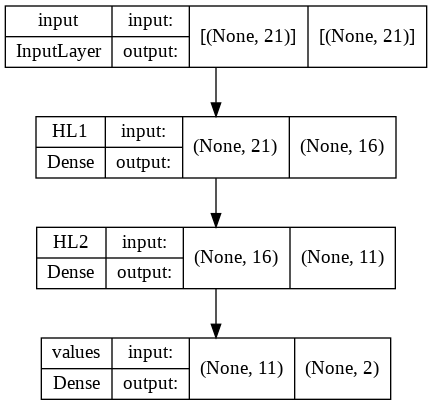

In [27]:
model = model_creator()
plot_model(model, show_shapes = True)

In [28]:
class SaveBestModel(tf.keras.callbacks.Callback):
    def __init__(self, save_best_metric='val_loss', this_max=False):
        self.save_best_metric = save_best_metric
        self.max = this_max
        if this_max:
            self.best = float('-inf')
        else:
            self.best = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        metric_value = logs[self.save_best_metric]
        if self.max:
            if metric_value > self.best:
                self.best = metric_value
                self.best_weights = self.model.get_weights()

        else:
            if metric_value < self.best:
                self.best = metric_value
                self.best_weights= self.model.get_weights()

In [29]:
best_model_saver = SaveBestModel('val_loss')

model = model_creator()

lr = 0.001
ep = 1000
opt = optimizers.Adam(learning_rate=lr, decay=lr / ep)

model.compile(loss = 'mse', optimizer=opt)

history  = model.fit(x = x_train_scaled, y = y_train_scaled,
                     validation_split = 0.25, epochs = ep, callbacks=[best_model_saver])

model.set_weights(best_model_saver.best_weights)

Epoch 1/1000
9/9 [==============================] - 1s 22ms/step - loss: 0.4338 - val_loss: 0.3618
Epoch 2/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.2705 - val_loss: 0.2248
Epoch 3/1000
9/9 [==============================] - 0s 4ms/step - loss: 0.1715 - val_loss: 0.1545
Epoch 4/1000
9/9 [==============================] - 0s 5ms/step - loss: 0.1299 - val_loss: 0.1246
Epoch 5/1000
9/9 [==============================] - 0s 5ms/step - loss: 0.1149 - val_loss: 0.1107
Epoch 6/1000
9/9 [==============================] - 0s 6ms/step - loss: 0.1073 - val_loss: 0.1034
Epoch 7/1000
9/9 [==============================] - 0s 5ms/step - loss: 0.1025 - val_loss: 0.0982
Epoch 8/1000
9/9 [==============================] - 0s 5ms/step - loss: 0.0977 - val_loss: 0.0944
Epoch 9/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.0934 - val_loss: 0.0909
Epoch 10/1000
9/9 [==============================] - 0s 8ms/step - loss: 0.0896 - val_loss: 0.0877
Epoch 11/1000
9/9 

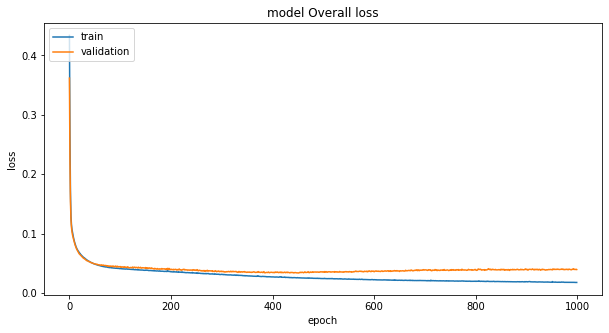

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model Overall loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# **Model Evaluation**

In [31]:
y_train_pred = model.predict(x_train_scaled)
y_test_pred = model.predict(x_test_scaled)

## Regression

### MSE Loss

In [32]:
from sklearn.metrics import mean_squared_error

mse_losses = {
    'train': mean_squared_error(y_train_pred, y_train_scaled),
    'test': mean_squared_error(y_test_pred, y_test_scaled)}

mse_losses

{'test': 0.04715741305896239, 'train': 0.027652985079411767}

### MAE Loss

In [33]:
from sklearn.metrics import mean_absolute_error
mae_losses_both = {
    'train': mean_absolute_error(y_train_pred, y_train_scaled),
    'test': mean_absolute_error(y_test_pred, y_test_scaled)}

mae_losses_both

{'test': 0.14738702577650203, 'train': 0.11770614248012404}

In [34]:
mae_losses_health_index = {
    'train': mean_absolute_error(y_train_pred[:, 0], y_train_scaled[:, 0]),
    'test': mean_absolute_error(y_test_pred[:, 0], y_test_scaled[:, 0])}

mae_losses_health_index

{'test': 0.10685633712580683, 'train': 0.09749898353431052}

In [35]:
mae_losses_life_expectation = {
    'train': mean_absolute_error(y_train_pred[:, 1], y_train_scaled[:, 1]),
    'test': mean_absolute_error(y_test_pred[:, 1], y_test_scaled[:, 1])}

mae_losses_life_expectation

{'test': 0.18791771442719726, 'train': 0.13791330142593794}